<a href="https://colab.research.google.com/github/25wh1a05az/NASSCOM/blob/main/U6_Probability_Statistics_Part1_Lab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Core imports for the whole lab
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid')
np.random.seed(42)

# We use the built-in 'tips' dataset (no file upload needed).
# In your own work this would be: pd.read_csv('data.csv')
df = sns.load_dataset('tips')
print('Loaded tips dataset:', df.shape)
df.head()

Loaded tips dataset: (244, 7)


,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


In [3]:
# 1. Numerical vs categorical columns

numerical_cols = df.select_dtypes(include='number').columns.tolist()
categorical_cols = df.select_dtypes(exclude='number').columns.tolist()

print("Numerical columns:", numerical_cols)
print("Categorical columns:", categorical_cols)


# 2. Mean of a numerical column (tip)

print("\nMean of tip:", df['tip'].mean())


# 3. Value counts of a categorical column (sex)

print("\nValue counts of sex:")
print(df['sex'].value_counts())

Numerical columns: ['total_bill', 'tip', 'size']
Categorical columns: ['sex', 'smoker', 'day', 'time']

Mean of tip: 2.99827868852459

Value counts of sex:
sex
Male      157
Female     87
Name: count, dtype: int64


Mean   : 19.79
Median : 17.8
Mode   : 13.42
mean > median ? True -> right-skewed


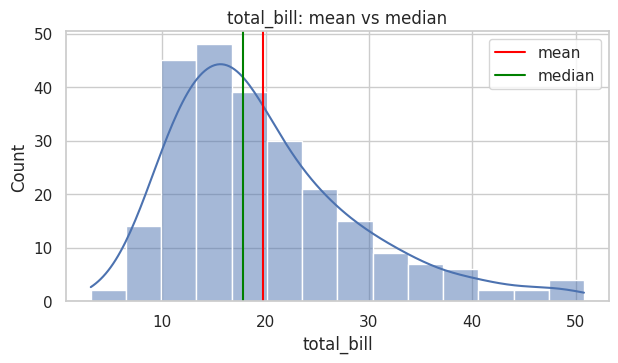

In [4]:


# -----------------------------------------------------------
# 🔹 2A. MEAN, MEDIAN, MODE
# -----------------------------------------------------------

col = df['total_bill']
print('Mean   :', round(col.mean(), 2))    # average; sensitive to outliers
print('Median :', round(col.median(), 2))  # middle value; robust to outliers
print('Mode   :', round(col.mode()[0], 2)) # most frequent value


# -----------------------------------------------------------
# 🔹 2B. WHEN MEAN AND MEDIAN DISAGREE (skew)
# -----------------------------------------------------------

# A right-skewed column drags the mean above the median
print('mean > median ?', col.mean() > col.median(), '-> right-skewed')

plt.figure(figsize=(7, 3.5))
sns.histplot(col, kde=True)
plt.axvline(col.mean(),   color='red',   label='mean')
plt.axvline(col.median(), color='green', label='median')
plt.legend(); plt.title('total_bill: mean vs median'); plt.show()



Mean: 2.99827868852459
Median: 2.9
Mode: 2.0

Mean > Median: True
The tip distribution is right-skewed.


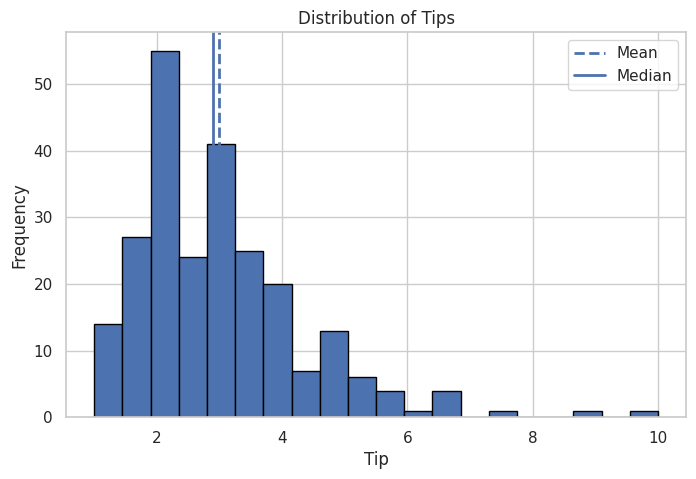

In [5]:
import matplotlib.pyplot as plt

tip = df['tip']

# 1. Mean, median, and mode
mean_tip = tip.mean()
median_tip = tip.median()
mode_tip = tip.mode()[0]

print("Mean:", mean_tip)
print("Median:", median_tip)
print("Mode:", mode_tip)


# 2. Check for right-skewness
print("\nMean > Median:", mean_tip > median_tip)

if mean_tip > median_tip:
    print("The tip distribution is right-skewed.")
else:
    print("The tip distribution is not right-skewed based on this check.")


# 3. Histogram with mean and median lines
plt.figure(figsize=(8, 5))

plt.hist(tip, bins=20, edgecolor='black')

plt.axvline(mean_tip, linestyle='--', linewidth=2, label='Mean')
plt.axvline(median_tip, linestyle='-', linewidth=2, label='Median')

plt.xlabel("Tip")
plt.ylabel("Frequency")
plt.title("Distribution of Tips")
plt.legend()

plt.show()

In [6]:


# -----------------------------------------------------------
# 🔹 3A. RANGE, VARIANCE, STANDARD DEVIATION
# -----------------------------------------------------------

col = df['total_bill']
print('Range :', round(col.max() - col.min(), 2))   # max - min
print('Var   :', round(col.var(), 2))                # variance (sigma^2)
print('Std   :', round(col.std(), 2))                # std deviation (sigma)


# -----------------------------------------------------------
# 🔹 3B. QUARTILES & THE INTERQUARTILE RANGE (IQR)
# -----------------------------------------------------------

q1, q3 = col.quantile(0.25), col.quantile(0.75)
iqr = q3 - q1
print('Q1 (25%):', round(q1, 2))
print('Q3 (75%):', round(q3, 2))
print('IQR     :', round(iqr, 2), '-> spread of the middle 50% (robust to outliers)')



Range : 47.74
Var   : 79.25
Std   : 8.9
Q1 (25%): 13.35
Q3 (75%): 24.13
IQR     : 10.78 -> spread of the middle 50% (robust to outliers)


In [7]:
tip = df['tip']

# 1. Range, variance, and standard deviation
tip_range = tip.max() - tip.min()
variance = tip.var()
std = tip.std()

print("Range:", tip_range)
print("Variance:", variance)
print("Standard deviation:", std)


# 2. Q1, Q3, and IQR
Q1 = tip.quantile(0.25)
Q3 = tip.quantile(0.75)
IQR = Q3 - Q1

print("\nQ1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)


# 3. Most robust measure of spread
# IQR is the most robust to outliers because it uses the middle 50%
# of the data and is not strongly affected by extreme values.

Range: 9.0
Variance: 1.9144546380624725
Standard deviation: 1.3836381890011826

Q1: 2.0
Q3: 3.5625
IQR: 1.5625


min     3.0700
25%    13.3475
50%    17.7950
75%    24.1275
max    50.8100
Name: total_bill, dtype: float64

Skewness: 1.133


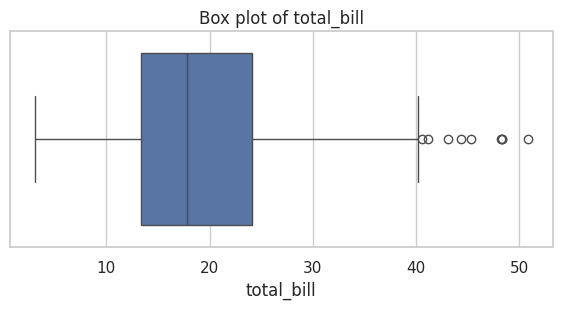

In [8]:


# -----------------------------------------------------------
# 🔹 4A. FIVE-NUMBER SUMMARY (min, Q1, median, Q3, max)
# -----------------------------------------------------------

col = df['total_bill']
five = col.describe()[['min', '25%', '50%', '75%', 'max']]
print(five)

# Skewness: > 0 means a right tail, < 0 a left tail, ~0 symmetric
print('\nSkewness:', round(col.skew(), 3))


# -----------------------------------------------------------
# 🔹 4B. BOX PLOT (a picture of the five-number summary)
# -----------------------------------------------------------

# The box spans Q1..Q3 (the IQR), the line is the median,
# whiskers reach the rest, and dots beyond them are outliers.
plt.figure(figsize=(7, 2.8))
sns.boxplot(x=df['total_bill'])
plt.title('Box plot of total_bill'); plt.show()



Five-number summary:
min     1.0000
25%     2.0000
50%     2.9000
75%     3.5625
max    10.0000
Name: tip, dtype: float64

Skewness: 1.4654510370979401
The distribution leans right (positive skew).


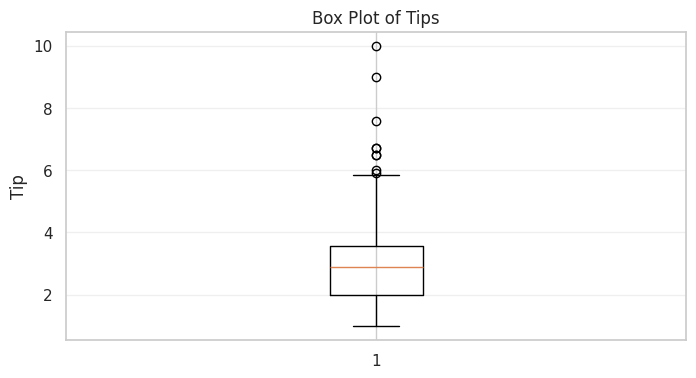

In [9]:
import matplotlib.pyplot as plt

tip = df['tip']

# 1. Five-number summary
five_number = tip.describe()[['min', '25%', '50%', '75%', 'max']]

print("Five-number summary:")
print(five_number)


# 2. Skewness
skewness = tip.skew()

print("\nSkewness:", skewness)

# Positive skewness means the distribution leans to the right.
# Negative skewness means the distribution leans to the left.
# The tip distribution is right-skewed.
if skewness > 0:
    print("The distribution leans right (positive skew).")
elif skewness < 0:
    print("The distribution leans left (negative skew).")
else:
    print("The distribution is approximately symmetric.")


# 3. Box plot
plt.figure(figsize=(8, 4))

plt.boxplot(tip)

plt.ylabel("Tip")
plt.title("Box Plot of Tips")
plt.grid(axis='y', alpha=0.3)

plt.show()

            total_bill   tip  size
total_bill        1.00  0.68  0.60
tip               0.68  1.00  0.49
size              0.60  0.49  1.00

total_bill vs tip: 0.68 -> strong positive


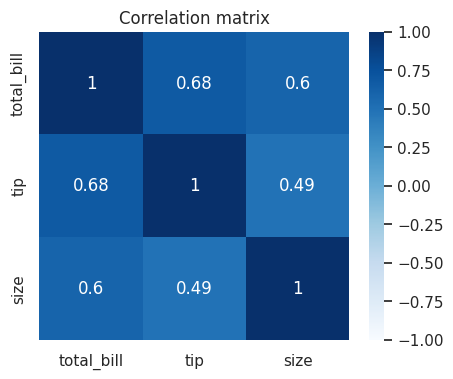

,total_bill,tip,size
count,244.000000,244.000000,244.000000
mean,19.785943,2.998279,2.569672
std,8.902412,1.383638,0.951100
min,3.070000,1.000000,1.000000
25%,13.347500,2.000000,2.000000
50%,17.795000,2.900000,2.000000
75%,24.127500,3.562500,3.000000
max,50.810000,10.000000,6.000000


In [10]:


# -----------------------------------------------------------
# 🔹 5A. CORRELATION between numerical columns
# -----------------------------------------------------------

# .corr() returns a matrix of correlations in the range -1 .. +1
corr = df.corr(numeric_only=True)
print(corr.round(2))

# correlation is NOT causation, and it only measures LINEAR relationships
print('\ntotal_bill vs tip:', round(corr.loc['total_bill', 'tip'], 2), '-> strong positive')


# -----------------------------------------------------------
# 🔹 5B. VISUALISE THE CORRELATION MATRIX
# -----------------------------------------------------------

plt.figure(figsize=(5, 4))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='Blues', vmin=-1, vmax=1)
plt.title('Correlation matrix'); plt.show()


# -----------------------------------------------------------
# 🔹 5C. ONE-SHOT SUMMARY with .describe()
# -----------------------------------------------------------

# describe() returns count, mean, std, min, quartiles and max for every numeric column
df.describe()



Correlation Matrix:
            total_bill   tip  size
total_bill        1.00  0.68  0.60
tip               0.68  1.00  0.49
size              0.60  0.49  1.00


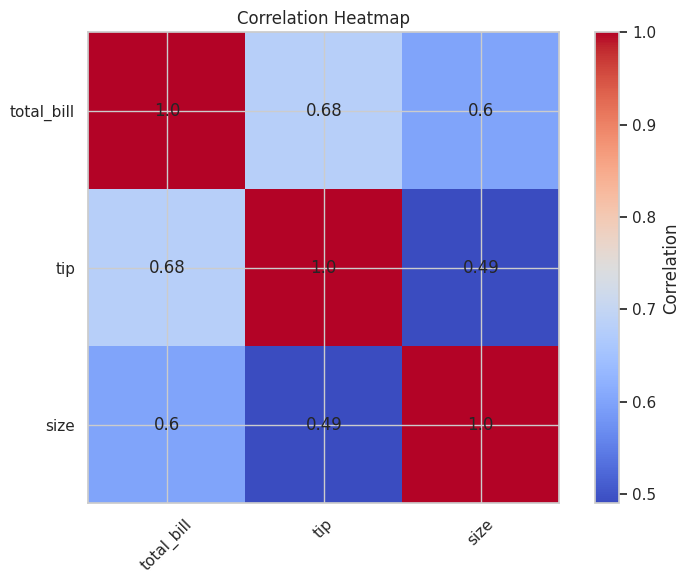


Descriptive Summary:
       total_bill         tip        size
count  244.000000  244.000000  244.000000
mean    19.785943    2.998279    2.569672
std      8.902412    1.383638    0.951100
min      3.070000    1.000000    1.000000
25%     13.347500    2.000000    2.000000
50%     17.795000    2.900000    2.000000
75%     24.127500    3.562500    3.000000
max     50.810000   10.000000    6.000000


In [11]:
import matplotlib.pyplot as plt

# 1. Correlation matrix (rounded to 2 decimals)
corr = df.corr(numeric_only=True).round(2)

print("Correlation Matrix:")
print(corr)


# 2. Heatmap of the correlation matrix
plt.figure(figsize=(8, 6))

plt.imshow(corr, cmap='coolwarm', interpolation='nearest')
plt.colorbar(label='Correlation')

plt.xticks(range(len(corr.columns)), corr.columns, rotation=45)
plt.yticks(range(len(corr.columns)), corr.columns)

# Add correlation values to the heatmap
for i in range(len(corr.columns)):
    for j in range(len(corr.columns)):
        plt.text(j, i, corr.iloc[i, j],
                 ha='center', va='center')

plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()


# 3. Full descriptive summary
print("\nDescriptive Summary:")
print(df.describe())


# Insight 1: total_bill has the largest standard deviation among
# the main numerical columns, so it has relatively high spread.

# Insight 2: total_bill and tip have a positive correlation,
# meaning larger bills generally tend to have larger tips.

# Insight 3: The tip distribution is positively/right-skewed,
# as its mean is greater than its median.